In [1]:
from myutils import *
from scipy.stats import norm
from hduq.cgh import *
# from hduq.spadeutils import *

In [2]:
def jinc(x):
    _type_check = False
    if type(x) in (int, float):
        x = [x]
        _type_check = True
    x = np.abs(np.array(x))

    from scipy.special import j1
    with np.errstate(invalid='ignore'):
        result = 2 * j1(x) / x
        
    result[np.isnan(result)] = 1

    if _type_check:
        return result.item()
    else:
        return result

In [3]:
def ThinLens(U_input):
    Ny, Nx = U_input.shape
    N = max(Nx, Ny)
    U_pad = np.zeros((N, N), dtype=complex)

    start_y = (N - Ny) // 2
    start_x = (N - Nx) // 2
    U_pad[start_y : start_y + Ny, start_x : start_x + Nx] = U_input

    U_focal_pad = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(U_pad)))
    U_focal = U_focal_pad[start_y : start_y + Ny, start_x : start_x + Nx]

    return U_focal

In [4]:
imshow_ = lambda arr: imshow(min_max_normalize(arr, 0, 5000), colorbar=False, figsize=(10, 5.625), pillow=False)

In [138]:
cgh = CGH(103, quiet=True)

cghs = []

def s(n):
    return 2 * 103 * np.sin(2*np.pi * 0.2 * n)

for s_ in tqdm([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]):
    cgh.clear_modes()

    cgh.add_modes(HG(0, s_, x_shift=0, y_shift=0), 500, 0)
    # cgh.add_modes(HG(0, 1, x_shift=0, y_shift=s_), 500, 150)
    # cgh.add_modes(HG(0, 2, x_shift=0, y_shift=s_), 700, 150)
    # cgh.add_modes(HG(0, 3, x_shift=0, y_shift=s_), 300, 0)
    # cgh.add_modes(HG(0, 4, x_shift=0, y_shift=s_), 500, 0)
    # cgh.add_modes(HG(0, 5, x_shift=0, y_shift=s_), 700, 0)
    # cgh.add_modes(HG(0, 6, x_shift=0, y_shift=s_), 300, -150)
    # cgh.add_modes(HG(0, 7, x_shift=0, y_shift=s_), 500, -150)
    # cgh.add_modes(HG(0, 8, x_shift=0, y_shift=s_), 700, -150)

    cghs.append(cgh.result())

100%|██████████| 11/11 [00:04<00:00,  2.38it/s]


In [146]:
x, y = fast_meshgrid(1920, 1080, 8)

def U_prime(cgh_result, sigma=103):
    circ_psf = 1 / (2*np.sqrt(np.pi*sigma**2)) * jinc(np.sqrt(x**2 + y**2) / sigma)
    gaus_psf = 1/np.sqrt(2*np.pi*sigma**2) * np.exp(- (x**2 + y**2) / (4*sigma**2))
    uniform_psf = np.ones(shape=(1080, 1920))
    return circ_psf * np.exp(1j * min_max_normalize(cgh_result, 0, 2*np.pi))

In [147]:
result = []

for cgh_ in tqdm(cghs):
    result.append(np.abs(ThinLens(U_prime(cgh_)))**2)


  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:04<00:00,  2.63it/s]


In [141]:
# imshow(min_max_normalize(np.array(result)[0, 150:900, 210:710]) * 2000, colorbar=False, figsize=(10, 10), title='GausPSF', save='gaus.svg')

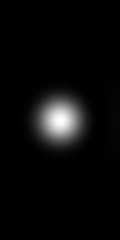

In [148]:
gifshow(np.array(result)[:, 380+40:710-50, 400:520], fps=1)

In [149]:
code(gifshow)